# Laboratorio 3 - SmartAlpes

## Integrantes

- Isabella Naranjo
- David Caro

## 1. Exploración de los datos

### Carga de datos

Verificamos que los datos se cargaron correctamente y analizamos su estructura.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/Datos_Laboratorio3.csv', delimiter=';', encoding='latin-1')
print("Verificamos que los datos cargaron correctamente: ")
pd.set_option('display.max_columns', None) 
pd.set_option('display.max_rows', 100)

print(df.head())
print('\n')
print(df.tail())
print('\nDimensiones del DataFrame: ')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Total de celdas: {df.size}")

Verificamos que los datos cargaron correctamente: 
   Edad     Gnereo   Peso  Altura    BMI     Objetivo     Condicion_salud  \
0    60  Masculino   73.7    1.61  28.43  Resistencia        Hipertension   
1    17   Femenino  121.0    1.97  31.18  Resistencia  Enfermedad corazon   
2    43  Masculino  110.0    1.52  47.61      General             Ninguno   
3    49       Otro   73.6    1.96  19.16      General             Ninguno   
4    53   Femenino   80.8    1.76  26.08  Resistencia        Hipertension   

  Nivel_Actividad Nivel_experiencia Dieta_preferida  Horas_sueño  \
0            Bajo          Avanzado          Vegano          5.5   
1        Moderado      Principiante     Vegetariano          6.9   
2            Bajo      Principiante  No-Vegetariano          6.0   
3        Moderado      Principiante  No-Vegetariano          5.7   
4            Alto      Principiante    Pescetariano          5.8   

  Entrenamiento_preferido  Cantidad_equipo  Tiempo_disponible  Tiene_alergia 

### Perfilamiento general del conjunto de datos

Realizamos un perfilamiento inicial para entender el tamaño del dataset, la distribución general de tipos de variables y el nivel global de completitud.

In [2]:
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

resumen_general = pd.DataFrame({
    'Métrica': [
        'Número de filas',
        'Número de columnas',
        'Variables numéricas',
        'Variables categóricas',
        'Total de valores faltantes',
        'Porcentaje global de valores faltantes (%)'
    ],
    'Valor': [
        df.shape[0],
        df.shape[1],
        len(variables_numericas),
        len(variables_categoricas),
        df.isnull().sum().sum(),
        round(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100, 4)
    ]
})

display(resumen_general)

,Métrica,Valor
0,Número de filas,9698.0000
1,Número de columnas,26.0000
2,Variables numéricas,17.0000
3,Variables categóricas,9.0000
4,Total de valores faltantes,11.0000
5,Porcentaje global de valores faltantes (%),0.0044


Verificamos que el tipo de variable del diccionario coincida con el tipo de variable de los datos en el dataset, y realizamos un primer acercamiento respecto a los valores nulos presentes en cada variable.

In [3]:
df.info()

variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f'Variables numéricas: {len(variables_numericas)}')
print(f'Variables categóricas: {len(variables_categoricas)}')

revision_tipos = pd.DataFrame({
    'Variable': df.columns,
    'Tipo actual': df.dtypes.astype(str).values
})

revision_tipos['Observación'] = ''

observaciones = {
    'Tiene_alergia': 'Numérica, pero semánticamente binaria/categórica',
    'Problemas_digestivos': 'Numérica, pero semánticamente binaria/categórica',
    'Fumador': 'Numérica, pero semánticamente binaria/categórica',
    'Alcohol': 'Numérica, pero semánticamente binaria/categórica',
    'Gnereo': 'Posible error tipográfico en el nombre de la variable'
}

for var, obs in observaciones.items():
    if var in revision_tipos['Variable'].values:
        revision_tipos.loc[revision_tipos['Variable'] == var, 'Observación'] = obs

display(revision_tipos)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9698 entries, 0 to 9697
Data columns (total 26 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Edad                     9698 non-null   int64  
 1   Gnereo                   9698 non-null   object 
 2   Peso                     9687 non-null   float64
 3   Altura                   9698 non-null   float64
 4   BMI                      9698 non-null   float64
 5   Objetivo                 9698 non-null   object 
 6   Condicion_salud          9698 non-null   object 
 7   Nivel_Actividad          9698 non-null   object 
 8   Nivel_experiencia        9698 non-null   object 
 9   Dieta_preferida          9698 non-null   object 
 10  Horas_sueño              9698 non-null   float64
 11  Entrenamiento_preferido  9698 non-null   object 
 12  Cantidad_equipo          9698 non-null   int64  
 13  Tiempo_disponible        9698 non-null   int64  
 14  Tiene_alergia           

,Variable,Tipo actual,Observación
0,Edad,int64,
1,Gnereo,object,Posible error tipográfico en el nombre de la v...
2,Peso,float64,
3,Altura,float64,
4,BMI,float64,
5,Objetivo,object,
6,Condicion_salud,object,
7,Nivel_Actividad,object,
8,Nivel_experiencia,object,
9,Dieta_preferida,object,


Realizamos un primer acercamiento a la exploración de outliers y valores imposibles en las variables númericas.

In [4]:
df.describe()

,Edad,Peso,Altura,BMI,Horas_sueño,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua
count,9698.000000,9687.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000,9698.000000
mean,45.112601,92.622515,1.775047,30.131391,7.004382,2.988039,67.194061,0.201588,0.153846,0.227366,2.172252,0.285317,3.778841,0.500115,129.997360,9765.936482,2.748532
std,17.641045,27.383913,0.158754,10.605675,1.449454,2.018493,30.839475,0.401207,0.360820,0.419153,4.624756,0.451588,7.023263,0.289062,51.981874,4762.152079,1.015342
min,15.000000,45.000000,1.500000,10.930000,0.000000,0.000000,15.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,200.000000,1.000000
25%,30.000000,68.800000,1.640000,21.620000,5.800000,1.000000,40.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.250000,85.000000,5608.250000,1.860000
50%,45.000000,92.600000,1.780000,29.190000,7.000000,3.000000,67.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.500000,129.950000,9718.000000,2.760000
75%,61.000000,116.500000,1.910000,37.060000,8.200000,5.000000,94.000000,0.000000,0.000000,0.000000,0.000000,1.000000,4.300000,0.750000,175.200000,13953.000000,3.620000
max,75.000000,140.000000,2.050000,62.090000,23.000000,6.000000,120.000000,1.000000,1.000000,1.000000,18.000000,1.000000,25.000000,1.000000,220.000000,17996.000000,4.500000


### Exploración univariada de variables numéricas

Analizamos la distribución, dispersión y posibles valores atípicos de las variables numéricas mediante estadísticas descriptivas, histogramas y diagramas de caja.

In [5]:
display(df[variables_numericas].describe().T)

,count,mean,std,min,25%,50%,75%,max
Edad,9698.0,45.112601,17.641045,15.00,30.00,45.00,61.00,75.00
Peso,9687.0,92.622515,27.383913,45.00,68.80,92.60,116.50,140.00
Altura,9698.0,1.775047,0.158754,1.50,1.64,1.78,1.91,2.05
BMI,9698.0,30.131391,10.605675,10.93,21.62,29.19,37.06,62.09
Horas_sueño,9698.0,7.004382,1.449454,0.00,5.80,7.00,8.20,23.00
Cantidad_equipo,9698.0,2.988039,2.018493,0.00,1.00,3.00,5.00,6.00
Tiempo_disponible,9698.0,67.194061,30.839475,15.00,40.00,67.00,94.00,120.00
Tiene_alergia,9698.0,0.201588,0.401207,0.00,0.00,0.00,0.00,1.00
Problemas_digestivos,9698.0,0.153846,0.360820,0.00,0.00,0.00,0.00,1.00
Fumador,9698.0,0.227366,0.419153,0.00,0.00,0.00,0.00,1.00


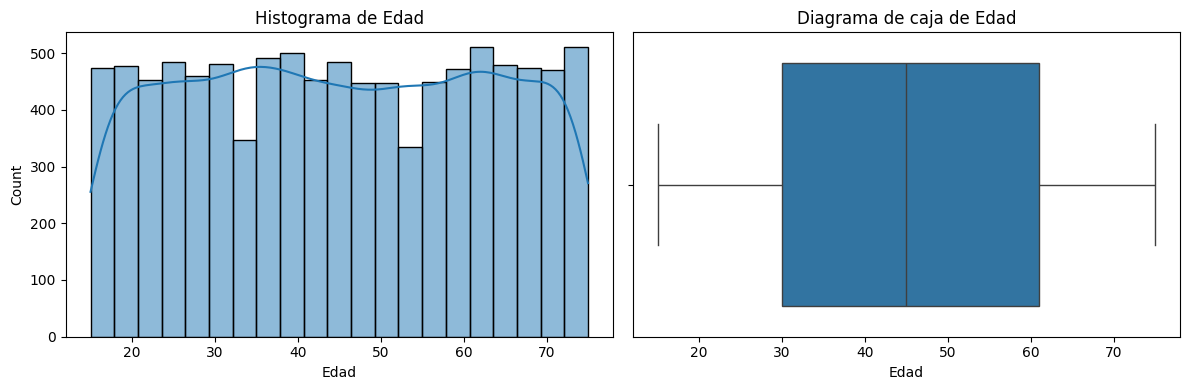

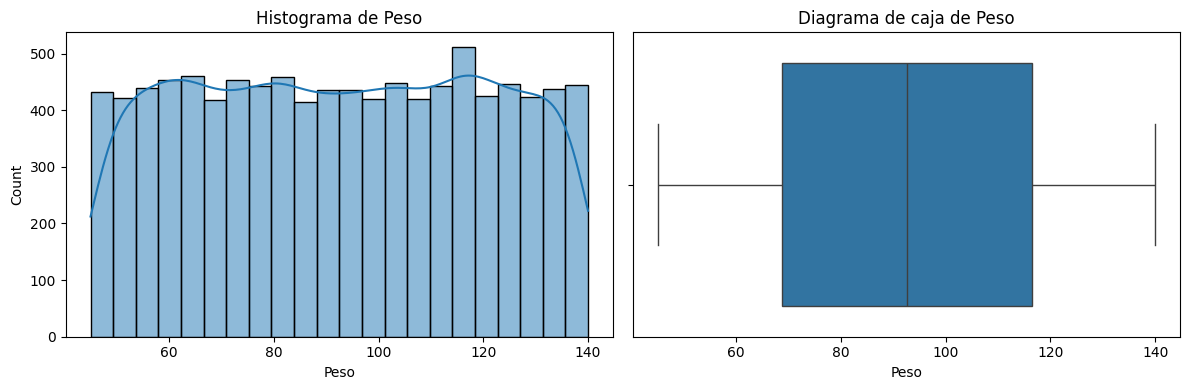

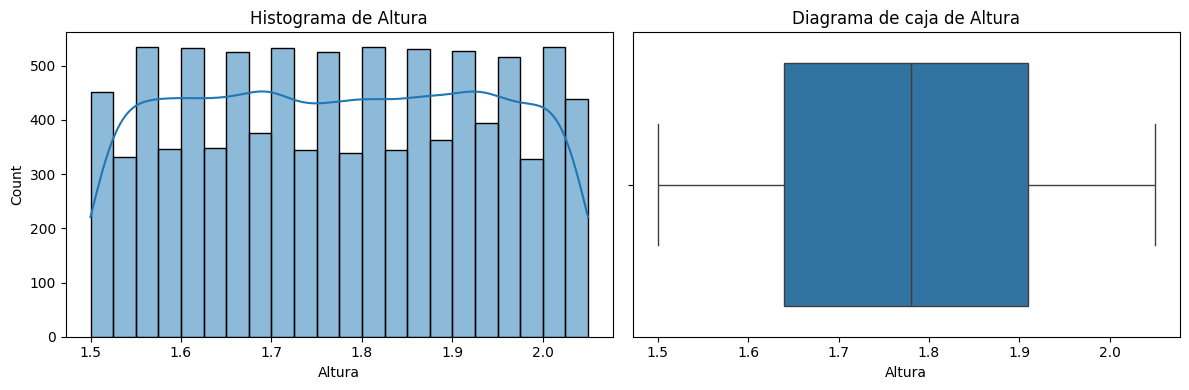

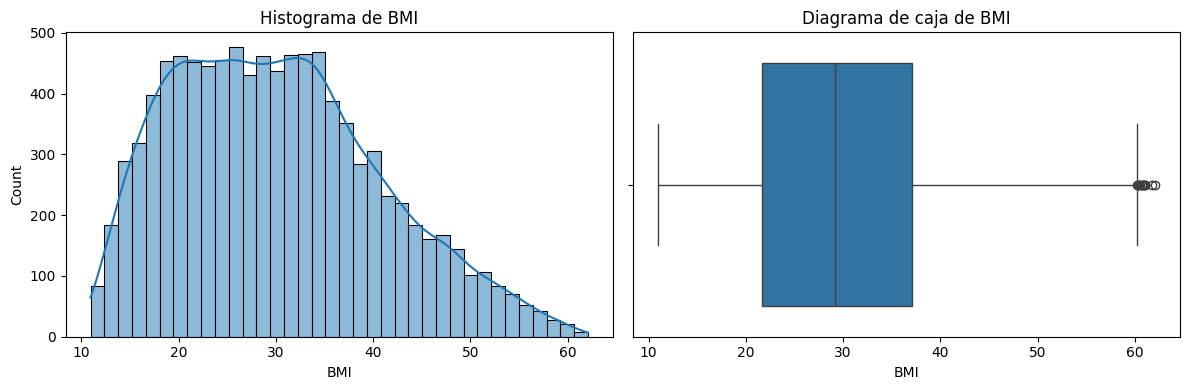

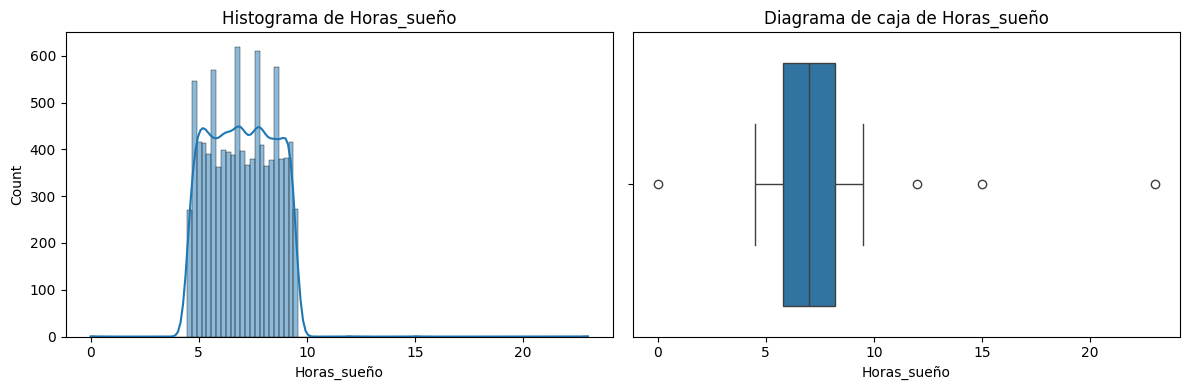

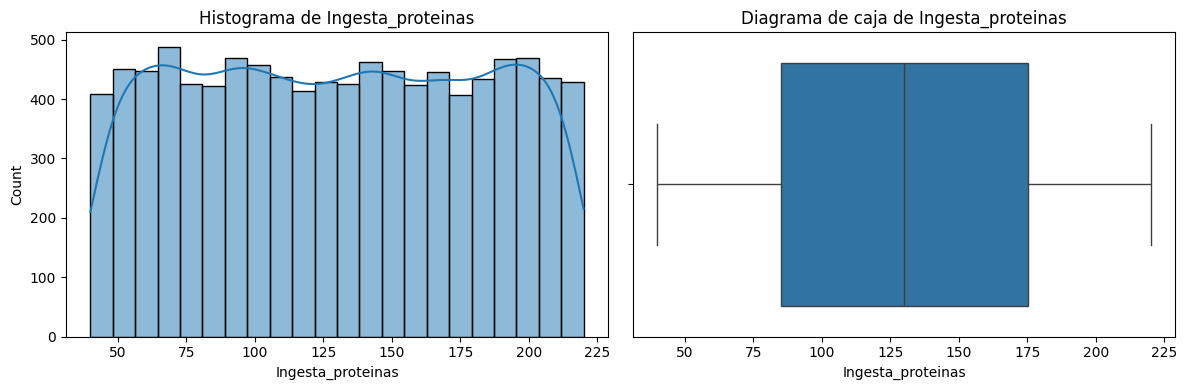

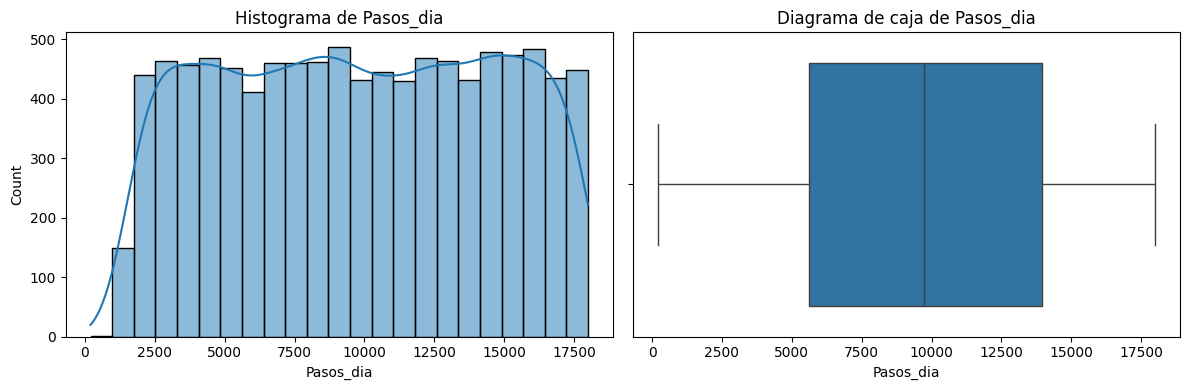

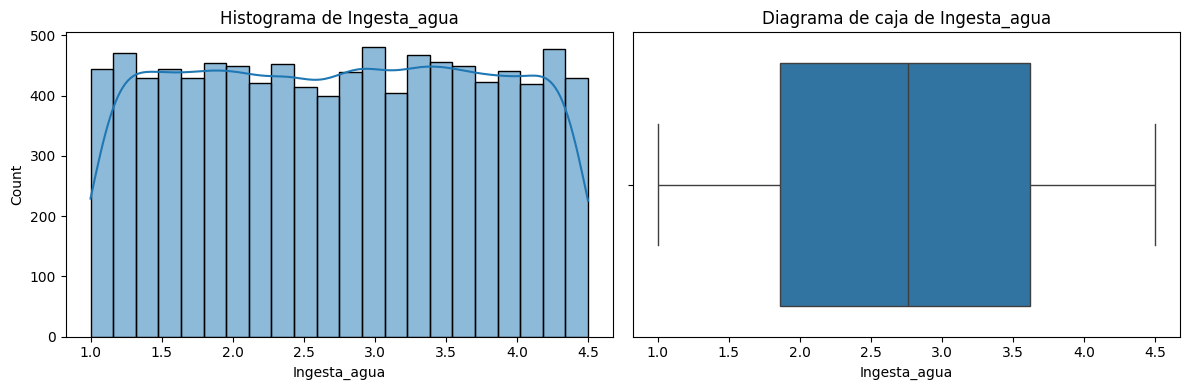

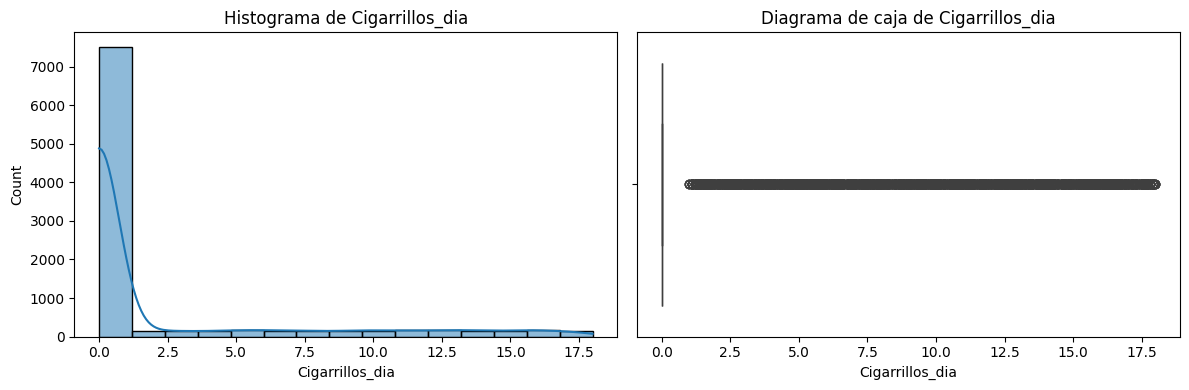

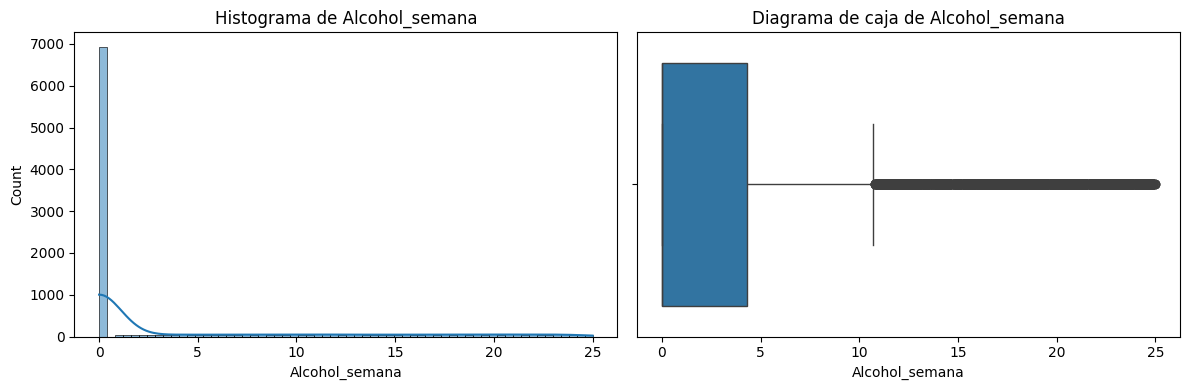

In [6]:
cols_numericas_clave = [
    'Edad', 'Peso', 'Altura', 'BMI', 'Horas_sueño',
    'Ingesta_proteinas', 'Pasos_dia', 'Ingesta_agua',
    'Cigarrillos_dia', 'Alcohol_semana'
]

cols_numericas_clave = [col for col in cols_numericas_clave if col in df.columns]

for col in cols_numericas_clave:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    sns.histplot(df[col], kde=True, ax=axes[0])
    axes[0].set_title(f'Histograma de {col}')
    
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f'Diagrama de caja de {col}')
    
    plt.tight_layout()
    plt.show()

Exploramos problemas de calidad relacionados con las variables categoricas.

In [7]:
resumen_categoricas = pd.DataFrame({
    'Variable': variables_categoricas,
    'Número de categorías únicas': [df[col].nunique() for col in variables_categoricas],
    'Valores faltantes': [df[col].isnull().sum() for col in variables_categoricas]
})

display(resumen_categoricas.sort_values(by='Número de categorías únicas', ascending=False))

,Variable,Número de categorías únicas,Valores faltantes
2,Condicion_salud,7,0
6,Entrenamiento_preferido,6,0
5,Dieta_preferida,5,0
1,Objetivo,5,0
7,Plan_entrenamiento,4,0
8,Plan_nutrición,4,0
0,Gnereo,3,0
4,Nivel_experiencia,3,0
3,Nivel_Actividad,3,0



Variable: Objetivo


,Frecuencia
Objetivo,
Ganancia muscular,2757
Perdida grasa,2594
General,2220
Resistencia,2123
grasa,4


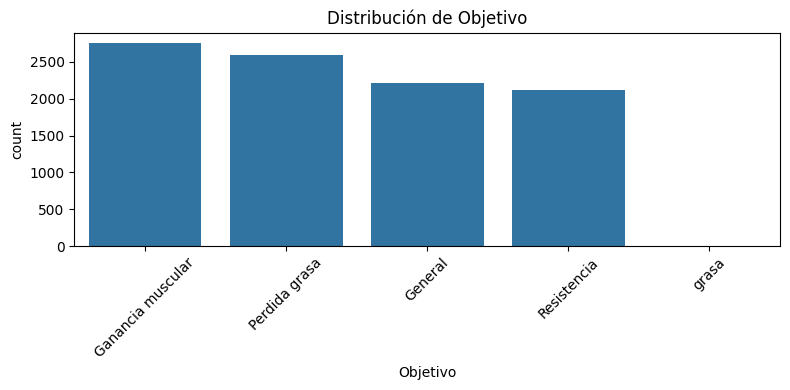


Variable: Dieta_preferida


,Frecuencia
Dieta_preferida,
No-Vegetariano,2456
Vegano,2426
Pescetariano,2403
Vegetariano,2402
Animal,11


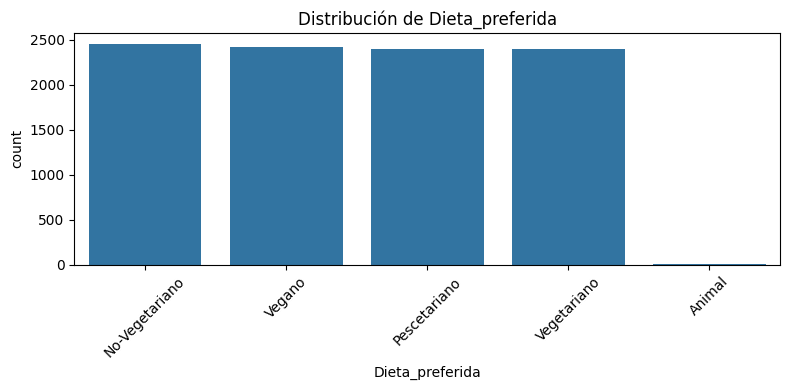


Variable: Condicion_salud


,Frecuencia
Condicion_salud,
Ninguno,6030
Hipertension,814
Lesion,764
Asma,745
Diabetes,511
Enfermedad corazon,497
PCOS,337


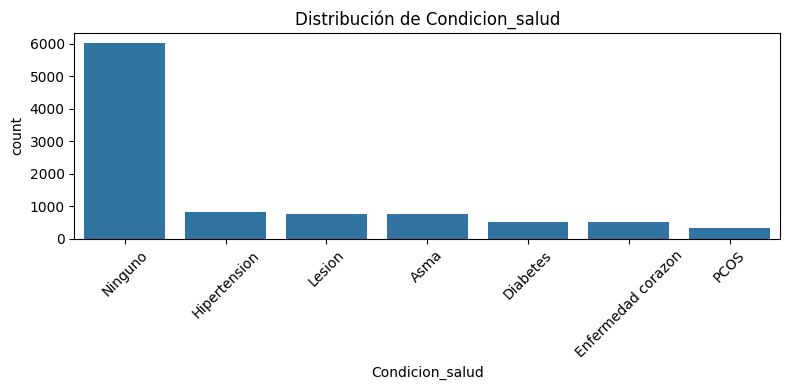


Variable: Gnereo


,Frecuencia
Gnereo,
Femenino,4719
Masculino,4611
Otro,368


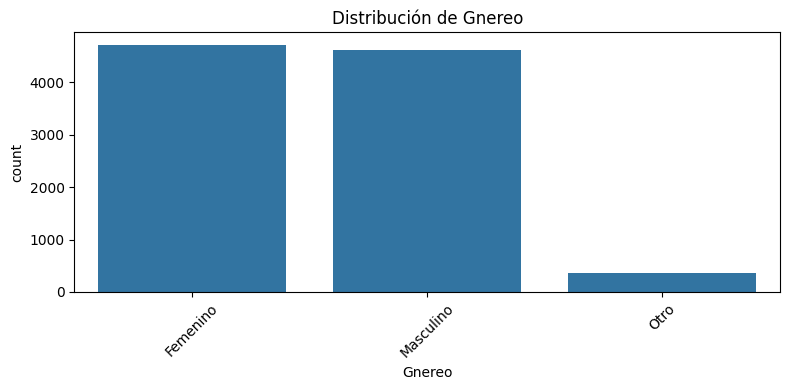


Variable: Plan_entrenamiento


,Frecuencia
Plan_entrenamiento,
Ninguno,3807
Medio,2945
Bajo,2290
Alto,656


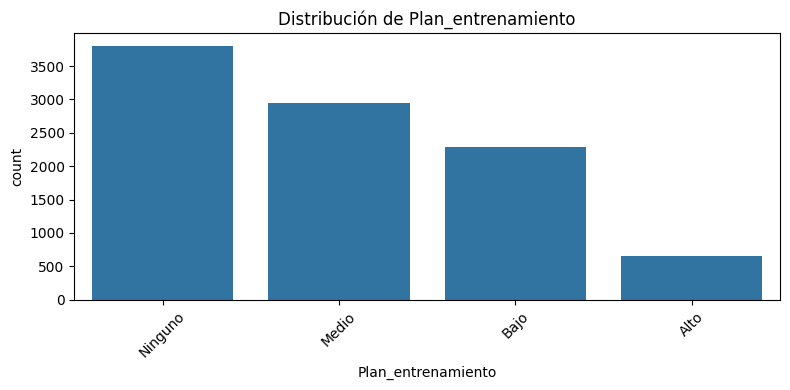


Variable: Plan_nutrición


,Frecuencia
Plan_nutrición,
Balanceado,4297
Sin plan,2522
Basico,2287
Especializado,592


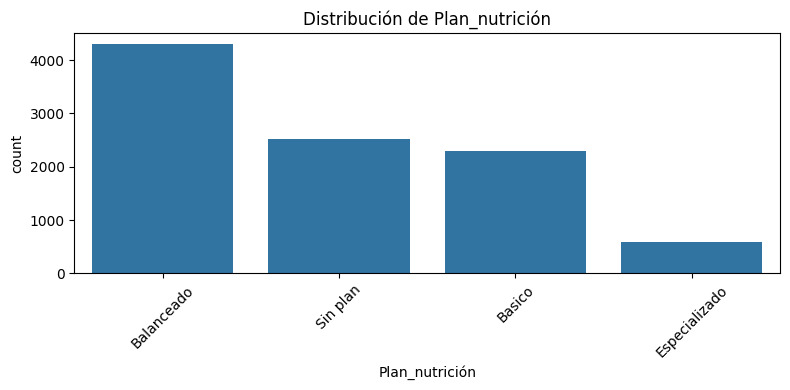

In [8]:
categoricas_clave = [
    'Objetivo', 'Dieta_preferida', 'Condicion_salud',
    'Nivel_actividad', 'Experiencia', 'Gnereo',
    'Plan_entrenamiento', 'Plan_nutrición'
]

categoricas_clave = [col for col in categoricas_clave if col in df.columns]

for col in categoricas_clave:
    print(f'\nVariable: {col}')
    display(df[col].value_counts(dropna=False).to_frame('Frecuencia'))
    
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, order=df[col].value_counts().index)
    plt.title(f'Distribución de {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

Exploramos las categorias ambiguas y desbalanceadas de las variables **'Objetivo'** y **'Dieta_preferida'** para saber que hacer con ellas.

In [9]:
print(df[df['Objetivo'] == 'grasa'])
print('\n')
print(df[df['Dieta_preferida'] == 'Animal'])

      Edad     Gnereo   Peso  Altura    BMI Objetivo Condicion_salud  \
6165    63  Masculino  101.1    1.73  33.78    grasa         Ninguno   
6240    62  Masculino  112.0    1.55  46.62    grasa         Ninguno   
9691    18  Masculino   60.6    1.98  15.46    grasa          Lesion   
9692    54  Masculino   69.1    1.97  17.81    grasa         Ninguno   

     Nivel_Actividad Nivel_experiencia Dieta_preferida  Horas_sueño  \
6165            Bajo          Avanzado  No-Vegetariano          4.7   
6240        Moderado      Principiante          Vegano          5.2   
9691            Bajo        Intermedio    Pescetariano          4.6   
9692        Moderado      Principiante  No-Vegetariano          8.0   

     Entrenamiento_preferido  Cantidad_equipo  Tiempo_disponible  \
6165               Funcional                5                 39   
6240               Funcional                0                 97   
9691                 Balance                6                 84   
9692       

Realizamos la exploración de nulos, duplicados (completos, lógicos e inconsistencias) y outliers de las variables númericas.

In [10]:
# Exploración de nulos

valores_nulos_por_categoria = df.isnull().sum()
porcentaje_nulos_por_categoria = ((valores_nulos_por_categoria / len(df)) * 100).round(2)

nulos = pd.DataFrame({
    "Nulos": valores_nulos_por_categoria,
    "Porcentaje (%)": porcentaje_nulos_por_categoria
})

print(nulos[nulos['Nulos'] > 0])

# Exploración de duplicados identicos 

duplicados_identicos = df.duplicated().sum()
print(f"\nDuplicados identicos: {duplicados_identicos}")

# Exploración de inconsistencias

# ¿Hay cigarrillos registrados en personas que dicen no fumar?
mask = (df['Cigarrillos_dia'] > 0) & (df['Fumador'] == 0)
print(f"\nCigarrillos sin ser fumador: {mask.sum()}")

# ¿Hay consumo de alcohol en personas que dicen no beber?
mask2 = (df['Alcohol_semana'] > 0) & (df['Alcohol'] == 0)
print(f"Alcohol_semana sin ser bebedor: {mask2.sum()}")

# Outliers 

# Variables que son realmente binarias o categóricas codificadas
binarias = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']

# Solo aplicar IQR a variables verdaderamente continuas
variables_continuas = [col for col in variables_numericas if col not in binarias]

for col in variables_continuas:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5 * IQR) | (df[col] > Q3 + 1.5 * IQR)]
    print(f"\n{col}: {len(outliers)} outliers estadísticos | min={df[col].min()} max={df[col].max()}")

      Nulos  Porcentaje (%)
Peso     11            0.11

Duplicados identicos: 0

Cigarrillos sin ser fumador: 0
Alcohol_semana sin ser bebedor: 0

Edad: 0 outliers estadísticos | min=15 max=75

Peso: 0 outliers estadísticos | min=45.0 max=140.0

Altura: 0 outliers estadísticos | min=1.5 max=2.05

BMI: 12 outliers estadísticos | min=10.93 max=62.09

Horas_sueño: 4 outliers estadísticos | min=0.0 max=23.0

Cantidad_equipo: 0 outliers estadísticos | min=0 max=6

Tiempo_disponible: 0 outliers estadísticos | min=15 max=120

Cigarrillos_dia: 2205 outliers estadísticos | min=0.0 max=18.0

Alcohol_semana: 1695 outliers estadísticos | min=0.0 max=25.0

Score_micronutrientes: 0 outliers estadísticos | min=0.0 max=1.0

Ingesta_proteinas: 0 outliers estadísticos | min=40.0 max=220.0

Pasos_dia: 0 outliers estadísticos | min=200 max=17996

Ingesta_agua: 0 outliers estadísticos | min=1.0 max=4.5


Exploramos valores sospechosos que son candidatos a ser imposibles de las diferentes variables según rangos razonables.

In [11]:
rangos = {
    'Edad':               (15, 75),
    'Peso':               (30, 200),
    'Altura':             (1.40, 2.20),
    'BMI':                (10, 60),
    'Horas_sueño':        (3, 14),
    'Ingesta_proteinas':  (20, 300),
    'Pasos_dia':          (0, 50000),
    'Ingesta_agua':       (0.5, 6),
    'Score_micronutrientes': (0, 1),
    'Cigarrillos_dia':    (0, 20),
    'Alcohol_semana':     (0, 50),
    'Tiempo_disponible':  (15, 120),
    'Cantidad_equipo':    (0, 6),
}

print('Valores Sospechosos: ')

for col, (minimo, maximo) in rangos.items():
    fuera = df[(df[col] < minimo) | (df[col] > maximo)]
    if len(fuera) > 0:
        print(f"{col}: {len(fuera)} valores fuera del rango [{minimo}, {maximo}]")
        print(fuera[[col]].to_string())
        print()
        
df['BMI_calculado'] = df['Peso'] / (df['Altura'] ** 2)
df['BMI_diferencia'] = abs(df['BMI'] - df['BMI_calculado'])

print('Exploración de valores sospechosos del BMI: ')
sospechosos = df[df['BMI'] > 60][['Peso', 'Altura', 'BMI', 'BMI_calculado', 'BMI_diferencia']]
print(sospechosos.round({'Peso': 1, 'Altura': 2, 'BMI': 2, 'BMI_calculado': 2, 'BMI_diferencia': 4}).to_string())
df.drop(columns=['BMI_calculado', 'BMI_diferencia'], inplace=True)

Valores Sospechosos: 
BMI: 16 valores fuera del rango [10, 60]
        BMI
221   60.22
1701  61.02
2531  60.80
2884  60.12
2891  60.47
2975  60.38
2997  61.78
3653  60.17
4369  60.70
5512  62.09
5728  61.09
6843  60.74
7411  60.26
7978  60.96
7995  60.57
9380  60.03

Horas_sueño: 3 valores fuera del rango [3, 14]
      Horas_sueño
2250         23.0
2627          0.0
9504         15.0

Exploración de valores sospechosos del BMI: 
       Peso  Altura    BMI  BMI_calculado  BMI_diferencia
221   137.3    1.51  60.22          60.22          0.0033
1701  137.3    1.50  61.02          61.02          0.0022
2531  136.8    1.50  60.80          60.80          0.0000
2884  138.9    1.52  60.12          60.12          0.0005
2891  139.7    1.52  60.47          60.47          0.0043
2975  139.5    1.52  60.38          60.38          0.0008
2997  139.0    1.50  61.78          61.78          0.0022
3653  137.2    1.51  60.17          60.17          0.0028
4369  138.4    1.51  60.70          60.70    

En este caso tenemos 2 variables objetivo: **Plan de Entrenamiento** y **Plan de nutrición**. Realizamos 2 gráficas para poder ver la distribución de estas 2 variables objetivo e identificar si se evidencia un desbalance de clases.

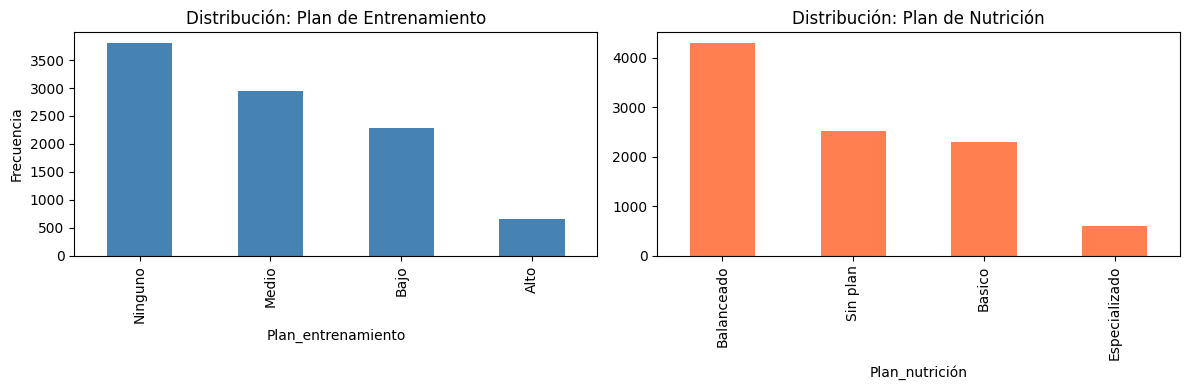

In [12]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Plan_entrenamiento'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Distribución: Plan de Entrenamiento')
axes[0].set_ylabel('Frecuencia')

df['Plan_nutrición'].value_counts().plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('Distribución: Plan de Nutrición')

plt.tight_layout()
plt.show()

Verificamos la consistencia de la categoria 'Sin plan' de **Plan_nutrición**.

In [13]:
condiciones_criticas = ['Diabetes', 'Hipertension', 'Enfermedad corazon', 'PCOS']

condicion_sin_plan = df[
    (df['Plan_nutrición'] == 'Sin plan') &
    (df['Condicion_salud'].isin(condiciones_criticas))
]

total_condiciones_criticas = df[df['Condicion_salud'].isin(condiciones_criticas)].shape[0]

print(f"Registros con condición crítica y 'Sin plan': {len(condicion_sin_plan)}")

if total_condiciones_criticas > 0:
    porcentaje = round(len(condicion_sin_plan) / total_condiciones_criticas * 100, 2)
    print(f"Porcentaje dentro de usuarios con condición crítica: {porcentaje}%")

display(condicion_sin_plan.head(15))

Registros con condición crítica y 'Sin plan': 583
Porcentaje dentro de usuarios con condición crítica: 27.0%


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,Entrenamiento_preferido,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,73.7,1.61,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,Funcional,3,98,0,0,0,0.0,0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,121.0,1.97,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,Funcional,4,105,0,0,0,0.0,0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
4,53,Femenino,80.8,1.76,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,Balance,3,120,0,1,1,8.7,0,0.0,0.98,51.1,12774,1.90,Medio,Sin plan
6,34,Femenino,101.9,2.05,24.25,General,Hipertension,Alto,Intermedio,Pescetariano,8.3,Flexibilidad,4,23,0,0,0,0.0,0,0.0,0.51,205.6,11066,1.52,Bajo,Sin plan
32,54,Femenino,82.4,1.86,23.82,General,Diabetes,Bajo,Principiante,Vegano,4.7,Balance,5,72,0,0,0,0.0,0,0.0,0.99,122.8,6493,1.19,Ninguno,Sin plan
59,49,Masculino,122.9,1.93,32.99,General,Hipertension,Bajo,Principiante,Pescetariano,5.3,Balance,4,66,0,0,1,16.6,0,0.0,0.69,213.3,13218,1.04,Ninguno,Sin plan
65,51,Femenino,113.8,2.02,27.89,Resistencia,PCOS,Alto,Intermedio,Pescetariano,6.7,Cardio,6,105,0,0,0,0.0,0,0.0,0.12,131.4,13155,3.60,Medio,Sin plan
66,30,Masculino,68.9,2.01,17.05,Resistencia,PCOS,Moderado,Intermedio,Animal,5.4,Funcional,2,56,0,0,0,0.0,0,0.0,0.17,72.7,9946,1.76,Ninguno,Sin plan
76,31,Femenino,67.7,2.00,16.92,General,Diabetes,Moderado,Intermedio,No-Vegetariano,9.0,Funcional,3,60,0,0,0,0.0,0,0.0,0.40,194.0,3231,4.13,Ninguno,Sin plan
99,59,Masculino,99.0,1.90,27.42,General,Enfermedad corazon,Bajo,Intermedio,Vegetariano,7.9,Funcional,5,18,1,0,0,0.0,1,23.8,0.98,91.0,1898,2.37,Ninguno,Sin plan


Realizamos una matriz de correlación entre las variables para poder evidenciar redundancia entre las variables.

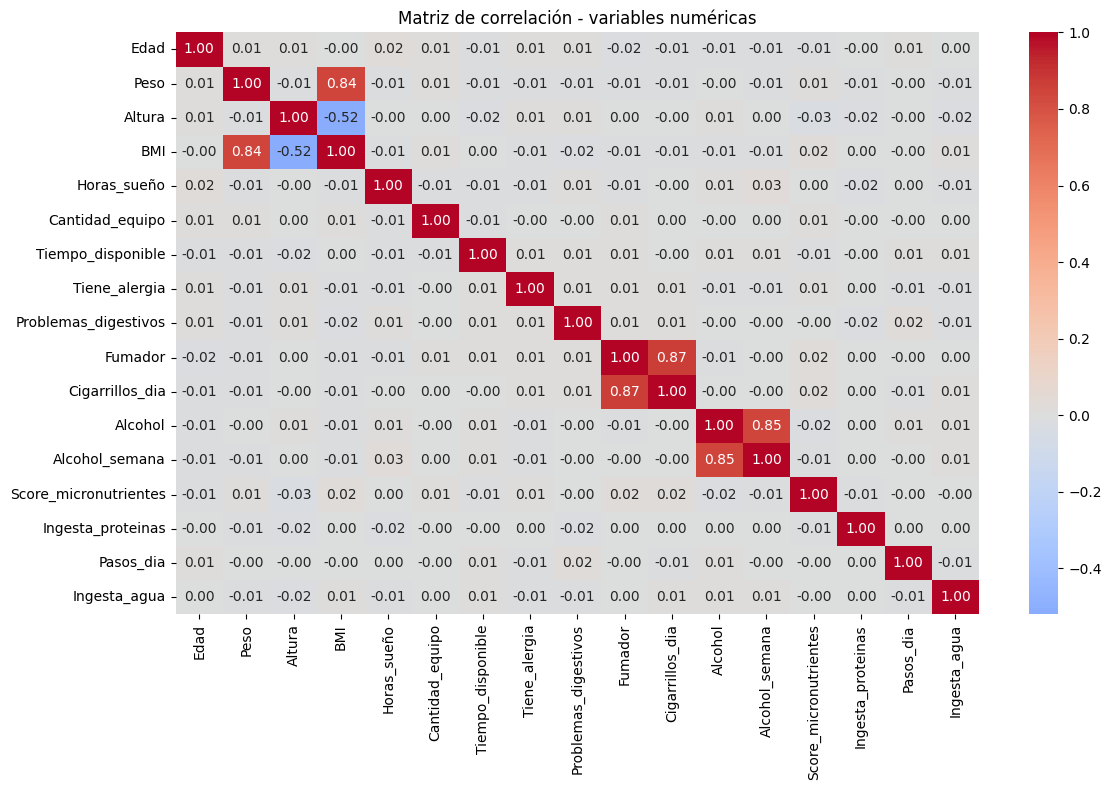

In [14]:
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.heatmap(df.select_dtypes(include='number').corr().round(2),
            annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Matriz de correlación - variables numéricas')
plt.tight_layout()
plt.show()

### Relación entre variables explicativas y variables objetivo

Exploramos algunas asociaciones iniciales entre variables del perfil de los usuarios y las recomendaciones asignadas.


Relación entre Objetivo y Plan_entrenamiento


Plan_entrenamiento,Alto,Bajo,Medio,Ninguno
Objetivo,,,,
Ganancia muscular,0.134,0.263,0.415,0.188
General,0.037,0.227,0.257,0.480
Perdida grasa,0.044,0.226,0.260,0.470
Resistencia,0.042,0.224,0.262,0.472
grasa,0.000,0.250,0.250,0.500


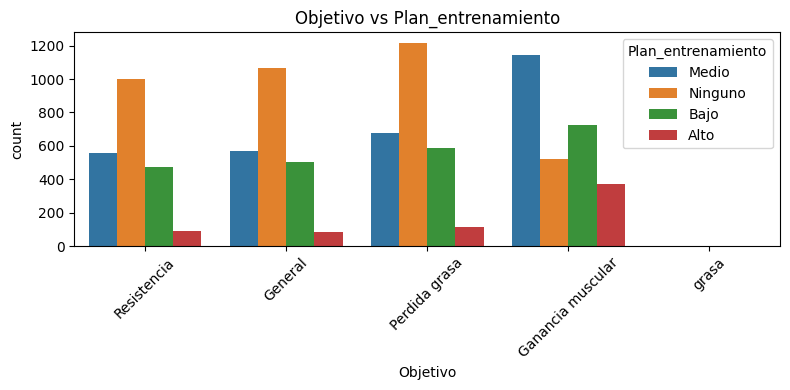


Relación entre Dieta_preferida y Plan_nutrición


Plan_nutrición,Balanceado,Basico,Especializado,Sin plan
Dieta_preferida,,,,
Animal,0.273,0.273,0.091,0.364
No-Vegetariano,0.427,0.236,0.063,0.274
Pescetariano,0.449,0.246,0.055,0.250
Vegano,0.441,0.227,0.063,0.270
Vegetariano,0.457,0.234,0.063,0.246


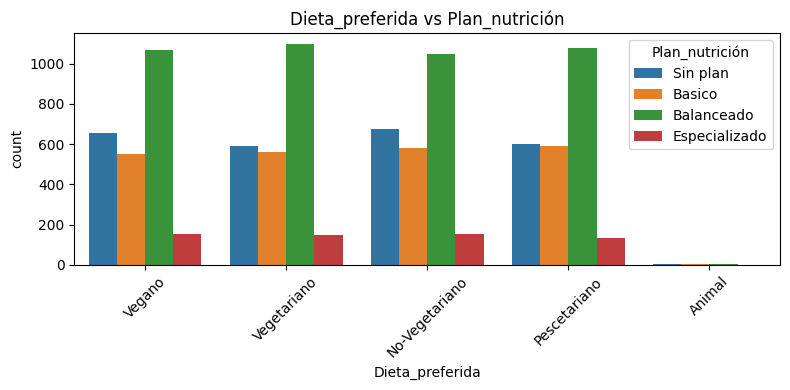


Relación entre Condicion_salud y Plan_nutrición


Plan_nutrición,Balanceado,Basico,Especializado,Sin plan
Condicion_salud,,,,
Asma,0.468,0.236,0.064,0.231
Diabetes,0.431,0.225,0.070,0.274
Enfermedad corazon,0.449,0.245,0.054,0.252
Hipertension,0.435,0.215,0.075,0.275
Lesion,0.436,0.230,0.063,0.271
Ninguno,0.443,0.239,0.059,0.259
PCOS,0.430,0.237,0.053,0.279


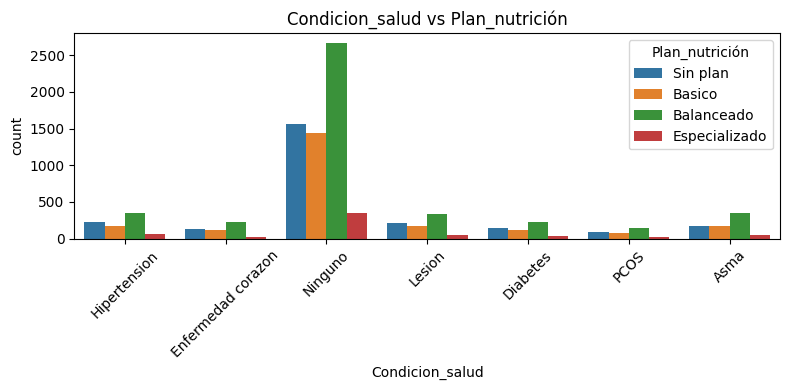

In [15]:
cruces = [
    ('Objetivo', 'Plan_entrenamiento'),
    ('Dieta_preferida', 'Plan_nutrición'),
    ('Condicion_salud', 'Plan_nutrición'),
    ('Nivel_actividad', 'Plan_entrenamiento')
]

for var_x, var_y in cruces:
    if var_x in df.columns and var_y in df.columns:
        print(f"\nRelación entre {var_x} y {var_y}")
        tabla = pd.crosstab(df[var_x], df[var_y], normalize='index').round(3)
        display(tabla)

        plt.figure(figsize=(8, 4))
        sns.countplot(data=df, x=var_x, hue=var_y)
        plt.title(f'{var_x} vs {var_y}')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

### Hallazgos de la exploración de los datos

A partir de la exploración realizada de los datos, pudimos identificar los siguientes problemas de calidad:

1. Todos los tipos de datos de las variables son consistentes con el diccionario, no obstante, las variables **('Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol')** son variables númericas binarias, que en terminos de la lógica del negocio representan una variable categorica **('Si', 'No')**. También se debe cambiar el nombre de la variable 'Gnereo' a 'Genero'.

2. Las variables categorias de **('Objetivo', 'Dieta_preferida')** tienen categorias ambiguas y muy desbalanceadas, 'grasa' y 'Animal' respectivamente. 'grasa' dado que únicamente está presente en 4 registros, y 'Animal' dado que solo está presente en 11 registros y existe la categoria 'No-Vegetariano'. Hallamos que la categoria de 'grasa' únicamente podria tener sentido con 2 registros, pero dada la lógica del negocio, planeamos eliminar esos 2 registros y actualizar los otros 2 registros con el objetivo más adecuado según el perfil de la persona, mientras que con la categoria de 'Animal', al no poder definir su consistencia, lo mejor es reemplazarla por la categoria de 'No-Vegetariano'.

3. Únicamente la variable **Peso** tiene 11 valores nulos y esta variable no tiene outliers, por tanto lo ideal es imputar estos valores nulos con la mediana, dado que aunque la variable no tiene outliers, la distribución de peso es amplia (45kg a 140 kg).

4. No hay duplicados completos ni lógicos y las variables correlacionadas son consistentes **('Altura', 'Peso', 'BMI', 'Cigarrilos_dia', 'Fumador', 'Alcohol_semana', 'Alcohol')**

5. Las variables **('BMI', 'Horas_sueño', 'Cigarrilos_dia', 'Alcohol_semana')** tiene outliers estadísticos, no obstante, por medio del análisis de valores imposibles hallamos que únicamente existen valores imposibles en la variable 'Horas_sueño', en donde el registro debe ser eliminado. Esto dado que los valores sospechosos hallados en la variable 'BMI' son consistentes con la altura y peso de la persona, y dada la lógica del negocio, lo mejor es dejarlos intactos. 'Cigarillos_dia' y 'Alcohol_semana' no tienen valores sospechosos, por tanto, idealmente se dejaran intactos sus outliers, pues son valores posibles. 

6. Existe un desbalance de clases en la distribución de las variables objetivo **Plan_entrenamiento** y **Plan_nutrición**. Por otro lado, el proceso de asignación de planes puede ser sesgado, pues existen personas con condiciones médicas que requieren un plan nutricional, y sin embargo, no tienen plan nutricional.

7. Hay variables muy correlacionadas que pueden llegar a ser redundantes, como ('Altura', 'Peso') y 'BMI', junto con 'Alcohol' y 'Alcohol_semana', y 'Fumador' y 'Cigarrilos_dia'. Se puede considerar dejar unicamente 'BMI', 'Cigarrillos_dia', y 'Alcohol_semana' pues interpretan la misma información.

## 2. Preparación de los datos 

### Propuesta de limpieza y preparación de los datos

Con base en los hallazgos de la exploración, en esta sección realizaremos la preparación de los datos para los modelos de clasificación, la preparación tendrá como objetivo lo siguiente:

1. Corregir problemas de calidad identificados en la exploración.
2. Adaptar los datos a la tarea de clasificación.
3. Adaptar los datos al algoritmo de aprendizaje que se va a utilizar.

Dado que se construirán cuatro modelos en total, vamos a implementar la preparación de forma modular mediante funciones. De esta manera, tendremos un proceso compacto y reutilizable.

### 2.1. Librerías para la preparación y construcción de preprocesadores

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

### 2.2. Función de limpieza base

Vamos a definir una función que aplica las decisiones de limpieza tomadas a partir de la exploración, esta función realiza únicamente transformaciones previas al modelado y deja el dataset listo para separar variables objetivo y generar los preprocesadores.

Se incluyen parámetros para controlar manualmente el tratamiento de la categoría `grasa` en `Objetivo`, de manera que la implementación sea fiel a las decisiones que tomamos respecto a los 4 registros que encontramos en esta categoría.

In [17]:
def limpieza_base_smartalpes(df, idx_grasa_eliminar=None, mapa_grasa_actualizar=None, eliminar_horas_sueno_invalidas=True, reducir_redundancia=True):
    
    df_clean = df.copy()

    # 1) Renombrar variable "Gnereo" con typo
    if 'Gnereo' in df_clean.columns:
        df_clean = df_clean.rename(columns={'Gnereo': 'Genero'})

    # 2) Tratar binarias como categóricas lógicas
    binarias_logicas = ['Tiene_alergia', 'Problemas_digestivos', 'Fumador', 'Alcohol']
    for col in binarias_logicas:
        if col in df_clean.columns:
            df_clean[col] = df_clean[col].map({1: 'Si', 0: 'No'}).fillna(df_clean[col])

    # 3) Corregir categoría ambigua en Dieta_preferida
    if 'Dieta_preferida' in df_clean.columns:
        df_clean['Dieta_preferida'] = df_clean['Dieta_preferida'].replace({
            'Animal': 'No-Vegetariano'
        })

    # 4) Tratar manualmente los registros con Objetivo = 'grasa'.
    if 'Objetivo' in df_clean.columns:
        if idx_grasa_eliminar is not None and len(idx_grasa_eliminar) > 0:
            df_clean = df_clean.drop(index=idx_grasa_eliminar, errors='ignore')

        if mapa_grasa_actualizar is not None and len(mapa_grasa_actualizar) > 0:
            for idx, nuevo_objetivo in mapa_grasa_actualizar.items():
                if idx in df_clean.index:
                    df_clean.at[idx, 'Objetivo'] = nuevo_objetivo

    # 5) Eliminar registros con Horas_sueño imposibles (según lo acordado)
    if eliminar_horas_sueno_invalidas and 'Horas_sueño' in df_clean.columns:
        df_clean = df_clean[(df_clean['Horas_sueño'] >= 3) & (df_clean['Horas_sueño'] <= 14)]

    # 6) Reducir redundancia entre variables muy correlacionadas
    #    Se conserva BMI, Cigarrillos_dia y Alcohol_semana.
    if reducir_redundancia:
        columnas_a_eliminar = [col for col in ['Altura', 'Peso', 'Fumador', 'Alcohol'] if col in df_clean.columns]
        df_clean = df_clean.drop(columns=columnas_a_eliminar)

    return df_clean

### 2.3. Aplicación de la limpieza base

A continuación, vamos a ejectuar la limpieza base sobre el dataset original. En el caso de la categoría `grasa` de la variable `Objetivo`, se especifican explícitamente los registros que se eliminan y los que se actualizan.

In [18]:

idx_grasa_eliminar = [
    9691, 9692
]

mapa_grasa_actualizar = {
    6165: 'Perdida grasa',
    6240: 'Perdida grasa'
}

df_clean = limpieza_base_smartalpes(
    df,
    idx_grasa_eliminar=idx_grasa_eliminar,
    mapa_grasa_actualizar=mapa_grasa_actualizar,
    eliminar_horas_sueno_invalidas=True,
    reducir_redundancia=True
)

print('Dimensiones antes de limpieza base:', df.shape)
print("Dimensiones después de limpieza base:", df_clean.shape)
display(df_clean.head())

Dimensiones antes de limpieza base: (9698, 26)
Dimensiones después de limpieza base: (9693, 22)


,Edad,Genero,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,Entrenamiento_preferido,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Cigarrillos_dia,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,60,Masculino,28.43,Resistencia,Hipertension,Bajo,Avanzado,Vegano,5.5,Funcional,3,98,No,No,0.0,0.0,0.92,182.1,16485,2.49,Medio,Sin plan
1,17,Femenino,31.18,Resistencia,Enfermedad corazon,Moderado,Principiante,Vegetariano,6.9,Funcional,4,105,No,No,0.0,0.0,0.76,167.7,14256,2.04,Ninguno,Sin plan
2,43,Masculino,47.61,General,Ninguno,Bajo,Principiante,No-Vegetariano,6.0,Fuerza,1,88,No,No,0.0,0.0,0.34,104.9,3050,2.53,Bajo,Basico
3,49,Otro,19.16,General,Ninguno,Moderado,Principiante,No-Vegetariano,5.7,Funcional,5,96,No,No,0.0,0.0,0.71,59.5,2264,3.36,Ninguno,Sin plan
4,53,Femenino,26.08,Resistencia,Hipertension,Alto,Principiante,Pescetariano,5.8,Balance,3,120,No,Si,8.7,0.0,0.98,51.1,12774,1.90,Medio,Sin plan


### 2.4. Función para preparar el problema de clasificación

Como vamos a trabajar con dos variables objetivo distintas (`Plan_entrenamiento` y `Plan_nutrición`), creamos una función que separa automáticamente la matriz de entrada, la variable objetivo y los conjuntos de entrenamiento y prueba.

In [19]:
def preparar_split_clasificacion(df_clean, target_col, test_size=0.2, random_state=42):
   
    columnas_objetivo = ['Plan_entrenamiento', 'Plan_nutrición']
    columnas_a_quitar = [col for col in columnas_objetivo if col in df_clean.columns]

    X = df_clean.drop(columns=columnas_a_quitar)
    y = df_clean[target_col].copy()

    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=test_size,
        random_state=random_state,
        stratify=y
    )

    return X_train, X_test, y_train, y_test

### 2.5. Función para construir el preprocesador

Por el mismo hecho de que vamos a trabajar con 4 modelos, creamos una función de creación para los preprocesadores flexible, que adapta el tratamiento de las variables al algoritmo que estemos trabajando. Para regresión logística incluimos escalado en variables numérica (para árbol de decisión no se escala).

In [20]:
def construir_preprocesador(X_train, modelo='logistica'):
    
    num_cols = X_train.select_dtypes(include=['int64', 'float64']).columns.tolist()
    cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

    if modelo == 'logistica':
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ])
    elif modelo == 'arbol':
        numeric_transformer = Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median'))
        ])
    else:
        raise ValueError("El parámetro 'modelo' debe ser 'logistica' o 'arbol'.")

    categorical_transformer = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', numeric_transformer, num_cols),
            ('cat', categorical_transformer, cat_cols)
        ]
    )

    return preprocessor, num_cols, cat_cols

### 2.6. Función compacta de preparación para cada modelo

Con el fin de reutilizar el mismo flujo en los cuatro modelos, creamos una función compacta que realiza la partición de datos y construye el preprocesador correspondiente al algoritmo que estemos usando.

In [21]:
def preparar_experimento(df_clean, target_col, modelo='logistica', test_size=0.2, random_state=42):
    
    print('\n')
   
    X_train, X_test, y_train, y_test = preparar_split_clasificacion(
        df_clean=df_clean,
        target_col=target_col,
        test_size=test_size,
        random_state=random_state
    )

    preprocessor, num_cols, cat_cols = construir_preprocesador(X_train, modelo=modelo)

    print(f"Objetivo: {target_col}")
    print(f"Modelo: {modelo}")
    print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")
    print(f"Variables numéricas: {len(num_cols)}")
    print(f"Variables categóricas: {len(cat_cols)}")

    return {
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'preprocessor': preprocessor,
        'num_cols': num_cols,
        'cat_cols': cat_cols
    }

### 2.7. Preparación de los cuatro experimentos

Finalmente, vamos a preparar los datos para los cuatro modelos que vamos a implementar más adelante:
- Regresión Logística para `Plan_entrenamiento`
- Regresión Logística para `Plan_nutrición`
- Árbol de Decisión para `Plan_entrenamiento`
- Árbol de Decisión para `Plan_nutrición`

In [22]:
# 1) Logística - Plan_entrenamiento
exp_log_ent = preparar_experimento(
    df_clean=df_clean,
    target_col='Plan_entrenamiento',
    modelo='logistica'
)

# 2) Logística - Plan_nutrición
exp_log_nut = preparar_experimento(
    df_clean=df_clean,
    target_col='Plan_nutrición',
    modelo='logistica'
)

# 3) Árbol - Plan_entrenamiento
exp_tree_ent = preparar_experimento(
    df_clean=df_clean,
    target_col='Plan_entrenamiento',
    modelo='arbol'
)

# 4) Árbol - Plan_nutrición
exp_tree_nut = preparar_experimento(
    df_clean=df_clean,
    target_col='Plan_nutrición',
    modelo='arbol'
)



Objetivo: Plan_entrenamiento
Modelo: logistica
X_train: (7754, 20) | X_test: (1939, 20)
Variables numéricas: 11
Variables categóricas: 9


Objetivo: Plan_nutrición
Modelo: logistica
X_train: (7754, 20) | X_test: (1939, 20)
Variables numéricas: 11
Variables categóricas: 9


Objetivo: Plan_entrenamiento
Modelo: arbol
X_train: (7754, 20) | X_test: (1939, 20)
Variables numéricas: 11
Variables categóricas: 9


Objetivo: Plan_nutrición
Modelo: arbol
X_train: (7754, 20) | X_test: (1939, 20)
Variables numéricas: 11
Variables categóricas: 9


### 2.8. Justificación de las decisiones de preparación

Las decisiones de preparación adoptadas estan basadas en los hallazgos de la exploración previa y en las necesidades de los algoritmos que vamos a implementar.

En primer lugar, corregimos problemas de calidad identificados en la exploración, incluyendo el renombramiento de variables, el tratamiento de categorías ambiguas, la eliminación de registros con valores imposibles en `Horas_sueño` y la imputación de valores faltantes en `Peso`.

En segundo lugar, tratamos variables binarias como variables categóricas desde la lógica del negocio, y se aplicó codificación one-hot a las variables cualitativas para que puedan ser utilizadas por los algoritmos de clasificación.

En tercer lugar, reducimos la redundancia entre variables altamente correlacionadas, conservando las más informativas o más adecuadas para el problema, con el fin de disminuir complejidad y favorecer la interpretabilidad de resultados.

Finalmente, la imputación, codificación y escalado no las aplicamos directamente sobre todo el dataset, sino que las creamos en preprocesadores que vamos a integrar al pipeline de cada modelo, esto con el fin de evitar fuga de datos y asegurarnos de que las transformaciones se ajusten únicamente con los datos de entrenamiento.

## 3. Modelos de regresión logística

En esta sección vamos a desarrollar dos modelos de regresión logística:
- Uno para la recomendación de `Plan_entrenamiento`
- Otro para la recomendación de `Plan_nutrición`

Vamos a estructurar el proceso mediante un pipeline que integra el preprocesamiento y el modelo en un flujo reproducible. Adicionalemnte, vamor a implementar una búsqueda de hiperparámetros con validación cruzada, revisando el tipo de regularización y el solver utilizados.

### 3.1. Estrategia de modelado

La regresión logística es un algoritmo de clasificación que construye límites de decisión sobre el espacio de entrada y estima las probabilidades de pertenencia a  una clase, la vamos a usar para resolver la recomendación de planes de entrenamiento y la recomendación de planes de nutrición.

Para evitar data leakage, el preprocesamiento lo vamos a integrar dentro del pipeline, para así asegurarnos de que imputación, codificación y escalado se ajusten solo con los datos de entrenamiento en cada partición que se haga dentro de la validación cruzada.

La búsqueda de hiperparámetros explora:
- el tipo de regularización (`l1`, `l2`)
- el solver
- el valor de `C`, que controla la fuerza de la regularización

En regresión logística, valores más altos de `C` implican menor regularización, por ende, modelos más complejos.

### 3.2. Librerías para la construcción y evaluación de los modelos

In [23]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 3.3. Función para entrenar un modelo de regresión logística

Creamos una función reutilizable que hace lo siguiente:
1. Recibe la información del experimento ya preparada
2. Construye un pipeline con el preprocesador y la regresión logística
3. Ejecuta una búsqueda de hiperparámetros con validación cruzada 
4. Evalúa el mejor modelo sobre el conjunto de prueba
5. Retorna el mejor estimador y un resumen de métricas

In [24]:
def entrenar_regresion_logistica(experimento, nombre_objetivo, scoring='f1_macro', cv_splits=5, random_state=42):

    X_train = experimento['X_train']
    X_test = experimento['X_test']
    y_train = experimento['y_train']
    y_test = experimento['y_test']
    preprocessor = experimento['preprocessor']

    pipeline_log = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', LogisticRegression(max_iter=5000, random_state=random_state))
    ])

    param_grid = [
        {
            'model__penalty': ['l2'],
            'model__solver': ['lbfgs', 'newton-cg', 'sag'],
            'model__C': [0.01, 0.1, 1, 10]
        },
        {
            'model__penalty': ['l1', 'l2'],
            'model__solver': ['liblinear'],
            'model__C': [0.01, 0.1, 1, 10]
        },
        {
            'model__penalty': ['l1', 'l2'],
            'model__solver': ['saga'],
            'model__C': [0.01, 0.1, 1, 10]
        }
    ]

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=random_state
    )

    grid = GridSearchCV(
        estimator=pipeline_log,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    resultados = {
        'Objetivo': nombre_objetivo,
        'Mejor score CV': grid.best_score_,
        'Mejor penalty': grid.best_params_['model__penalty'],
        'Mejor solver': grid.best_params_['model__solver'],
        'Mejor C': grid.best_params_['model__C'],
        'Accuracy test': accuracy_score(y_test, y_pred),
        'Precision macro test': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall macro test': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 macro test': f1_score(y_test, y_pred, average='macro', zero_division=0)
    }

    resultados = pd.DataFrame([resultados])

    return {
        'grid': grid,
        'best_model': best_model,
        'resultados': resultados,
        'y_test': y_test,
        'y_pred': y_pred
    }

### 3.4. Modelo de regresión logística para `Plan_entrenamiento`

Ahora vamos a entrenar el primer modelo de regresión logística para predecir la recomendación de plan de entrenamiento, la selección de hiperparámetros se hico con validación cruzada y usando `F1_macro` como criterio de optimización.

In [25]:
log_entrenamiento = entrenar_regresion_logistica(
    experimento=exp_log_ent,
    nombre_objetivo='Plan_entrenamiento',
    scoring='f1_macro'
)

display(log_entrenamiento['resultados'])

# mostrar mejores hiperparametros y reporte de clasificación
print("Mejores hiperparámetros para Plan_entrenamiento:")
print(log_entrenamiento['grid'].best_params_)

print("\nReporte de clasificación en test:")
print(classification_report(
    log_entrenamiento['y_test'],
    log_entrenamiento['y_pred'],
    zero_division=0
))

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,Objetivo,Mejor score CV,Mejor penalty,Mejor solver,Mejor C,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Plan_entrenamiento,0.880218,l1,saga,1,0.89737,0.888667,0.890689,0.889655


Mejores hiperparámetros para Plan_entrenamiento:
{'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'saga'}

Reporte de clasificación en test:
              precision    recall  f1-score   support

        Alto       0.89      0.91      0.90       131
        Bajo       0.81      0.81      0.81       458
       Medio       0.90      0.90      0.90       589
     Ninguno       0.94      0.95      0.95       761

    accuracy                           0.90      1939
   macro avg       0.89      0.89      0.89      1939
weighted avg       0.90      0.90      0.90      1939



### 3.5. Matriz de confusión del modelo para `Plan_entrenamiento`

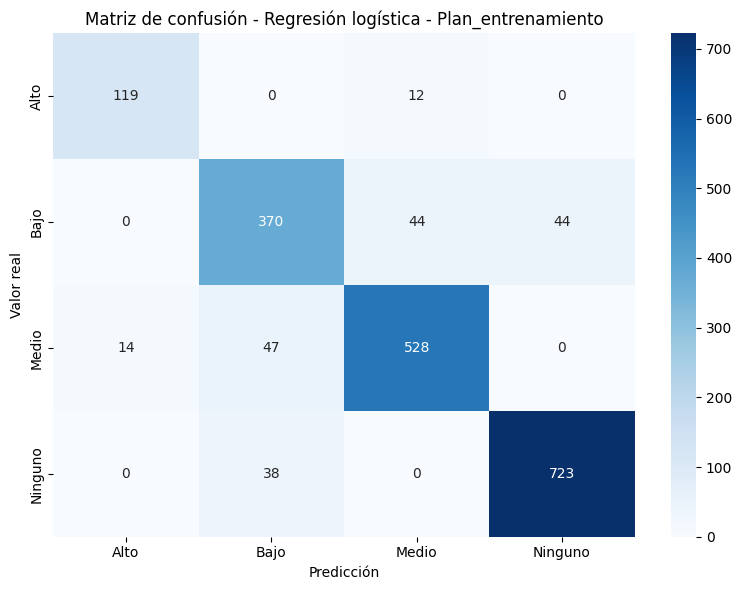

In [26]:
cm_ent = confusion_matrix(log_entrenamiento['y_test'], log_entrenamiento['y_pred'])
labels_ent = np.unique(log_entrenamiento['y_test'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_ent, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_ent, yticklabels=labels_ent)
plt.title('Matriz de confusión - Regresión logística - Plan_entrenamiento')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

### 3.6. Modelo de regresión logística para `Plan_nutrición`

Ahora vamos a entrenar el segundo modelo de regresión logística para predecir la recomendación de plan nutricional, siguiendo el mismo esquema del primer modelo.

In [27]:
log_nutricion = entrenar_regresion_logistica(
    experimento=exp_log_nut,
    nombre_objetivo='Plan_nutrición',
    scoring='f1_macro'
)

display(log_nutricion['resultados'])

#mejores hiperparametros y reporte de clasificación
print("Mejores hiperparámetros para Plan_nutrición:")
print(log_nutricion['grid'].best_params_)

print("\nReporte de clasificación en test:")
print(classification_report(
    log_nutricion['y_test'],
    log_nutricion['y_pred'],
    zero_division=0
))

Fitting 5 folds for each of 28 candidates, totalling 140 fits


,Objetivo,Mejor score CV,Mejor penalty,Mejor solver,Mejor C,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Plan_nutrición,0.732926,l1,saga,1,0.786488,0.751092,0.696707,0.71637


Mejores hiperparámetros para Plan_nutrición:
{'model__C': 1, 'model__penalty': 'l1', 'model__solver': 'saga'}

Reporte de clasificación en test:
               precision    recall  f1-score   support

   Balanceado       0.81      0.88      0.84       859
       Basico       0.67      0.61      0.64       457
Especializado       0.67      0.42      0.52       118
     Sin plan       0.86      0.88      0.87       505

     accuracy                           0.79      1939
    macro avg       0.75      0.70      0.72      1939
 weighted avg       0.78      0.79      0.78      1939



### 3.7. Matriz de confusión del modelo para `Plan_nutrición`

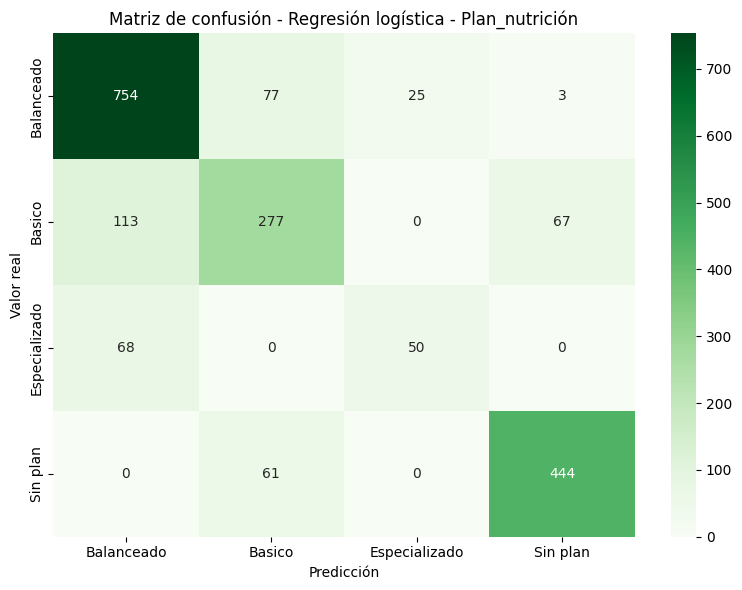

In [28]:
cm_nut = confusion_matrix(log_nutricion['y_test'], log_nutricion['y_pred'])
labels_nut = np.unique(log_nutricion['y_test'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_nut, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_nut, yticklabels=labels_nut)
plt.title('Matriz de confusión - Regresión logística - Plan_nutrición')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

### 3.8. Resumen de resultados de los modelos de regresión logística

In [29]:
resumen_logistica = pd.concat([
    log_entrenamiento['resultados'],
    log_nutricion['resultados']
], ignore_index=True)

display(resumen_logistica)

mejor_log_ent = log_entrenamiento['best_model']
mejor_log_nut = log_nutricion['best_model']

,Objetivo,Mejor score CV,Mejor penalty,Mejor solver,Mejor C,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Plan_entrenamiento,0.880218,l1,saga,1,0.897370,0.888667,0.890689,0.889655
1,Plan_nutrición,0.732926,l1,saga,1,0.786488,0.751092,0.696707,0.716370


### 3.9. Conclusión de la regresión logística

A partir de los resultados obtenidos, se observa que el modelo de regresión logística para `Plan_entrenamiento` presenta un desempeño superior en comparación con el modelo de `Plan_nutrición`, tanto en validación cruzada como en el conjunto de prueba. En particular, el F1-score macro es significativamente más alto en el primer caso, lo que indica una mejor capacidad para balancear precisión y recall entre las diferentes clases.

Por otro lado, el modelo para `Plan_nutrición` muestra un rendimiento más bajo, especialmente en recall y F1-score, lo que sugiere una mayor dificultad para capturar correctamente todas las clases. Esto puede deberse a un mayor nivel de complejidad en la variable objetivo, posibles inconsistencias en la asignación de planes nutricionales o a un mayor ruido en los datos asociados a este problema.

En ambos casos, el proceso de búsqueda de hiperparámetros seleccionó configuraciones con regularización L1 y el solver `saga`.

## 4. Modelos basados en árboles de decisión

En esta sección vamos a implementar dos modelos basados en árboles de decisión:
- Uno para la recomendación de `Plan_entrenamiento`
- Otro para la recomendación de `Plan_nutrición`

### 4.1. Estrategia de modelado

Los árboles de decisión son modelos de clasificación que generan reglas de partición sobre las variables de entrada para separar las clases, ahora vamos a usarlos para resolver los mismos problemas de antes: la recomendación de planes de entrenamiento y la recomendación de planes de nutrición.

Al igual que en la regresión logística, integraremos el preprocesamiento dentro del pipeline para evitar data leakage y asegurarnos de que las transformaciones se ajusten solo con los datos de entrenamiento en cada partición de la validación cruzada.

La búsqueda de hiperparámetros explora:
- el criterio de división (`gini`, `entropy`)
- la profundidad máxima del árbol
- el número mínimo de muestras para dividir un nodo
- el número mínimo de muestras en una hoja

### 4.2. Librerías para la construcción y evaluación de los modelos basados en árboles

In [30]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

### 4.3. Función para entrenar un árbol de decisión

Vamos a crear una función reutilizable que hace lo siguiente:
1. recibe la información del experimento ya preparada
2. construye un pipeline con el preprocesador y el árbol de decisión
3. ejecuta una búsqueda de hiperparámetros con validación cruzada estratificada
4. evalúa el mejor modelo sobre el conjunto de prueba
5. retorna el mejor estimador y un resumen de métricas.

In [31]:
def entrenar_arbol_decision(experimento, nombre_objetivo, scoring='f1_macro', cv_splits=5, random_state=42):
    
    X_train = experimento['X_train']
    X_test = experimento['X_test']
    y_train = experimento['y_train']
    y_test = experimento['y_test']
    preprocessor = experimento['preprocessor']

    pipeline_tree = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('model', DecisionTreeClassifier(random_state=random_state))
    ])

    param_grid = {
        'model__criterion': ['gini', 'entropy'],
        'model__max_depth': [3, 5, 7, 10, None],
        'model__min_samples_split': [2, 5, 10, 20],
        'model__min_samples_leaf': [1, 2, 5, 10]
    }

    cv = StratifiedKFold(
        n_splits=cv_splits,
        shuffle=True,
        random_state=random_state
    )

    grid = GridSearchCV(
        estimator=pipeline_tree,
        param_grid=param_grid,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        refit=True,
        verbose=1
    )

    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X_test)

    resultados = {
        'Objetivo': nombre_objetivo,
        'Mejor score CV': grid.best_score_,
        'Mejor criterion': grid.best_params_['model__criterion'],
        'Mejor max_depth': grid.best_params_['model__max_depth'],
        'Mejor min_samples_split': grid.best_params_['model__min_samples_split'],
        'Mejor min_samples_leaf': grid.best_params_['model__min_samples_leaf'],
        'Accuracy test': accuracy_score(y_test, y_pred),
        'Precision macro test': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'Recall macro test': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'F1 macro test': f1_score(y_test, y_pred, average='macro', zero_division=0)
    }

    resultados = pd.DataFrame([resultados])

    return {
        'grid': grid,
        'best_model': best_model,
        'resultados': resultados,
        'y_test': y_test,
        'y_pred': y_pred
    }

### 4.4. Consideraciones sobre la búsqueda de hiperparámetros

Utilizamos `F1_macro` como criterio de optimización para mantener consistencia con la regresión logística y porque esta métrica resulta es la mejor cuando se tratan problemas multiclase con desbalance de clases.

En el caso de los árboles de decisión, no escalamos las variables numéricas dentro del preprocesador porque este tipo de modelo no depende de magnitudes comparables.

### 4.5. Modelo basado en árbol de decisión para `Plan_entrenamiento`

Vamos a entrenar el primer modelo basado en árbol de decisión para predecir la recomendación de plan de entrenamiento. 

In [32]:
tree_entrenamiento = entrenar_arbol_decision(
    experimento=exp_tree_ent,
    nombre_objetivo='Plan_entrenamiento',
    scoring='f1_macro'
)

display(tree_entrenamiento['resultados'])

#mejores hiperparametros y reporte de clasificación
print("Mejores hiperparámetros para Plan_entrenamiento:")
print(tree_entrenamiento['grid'].best_params_)

print("\nReporte de clasificación en test:")
print(classification_report(
    tree_entrenamiento['y_test'],
    tree_entrenamiento['y_pred'],
    zero_division=0
))

Fitting 5 folds for each of 160 candidates, totalling 800 fits


,Objetivo,Mejor score CV,Mejor criterion,Mejor max_depth,Mejor min_samples_split,Mejor min_samples_leaf,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Plan_entrenamiento,0.998947,entropy,5,2,1,0.998969,0.997682,0.99903,0.998352


Mejores hiperparámetros para Plan_entrenamiento:
{'model__criterion': 'entropy', 'model__max_depth': 5, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}

Reporte de clasificación en test:
              precision    recall  f1-score   support

        Alto       0.99      1.00      1.00       131
        Bajo       1.00      1.00      1.00       458
       Medio       1.00      1.00      1.00       589
     Ninguno       1.00      1.00      1.00       761

    accuracy                           1.00      1939
   macro avg       1.00      1.00      1.00      1939
weighted avg       1.00      1.00      1.00      1939



### 4.6. Matriz de confusión del modelo para `Plan_entrenamiento`

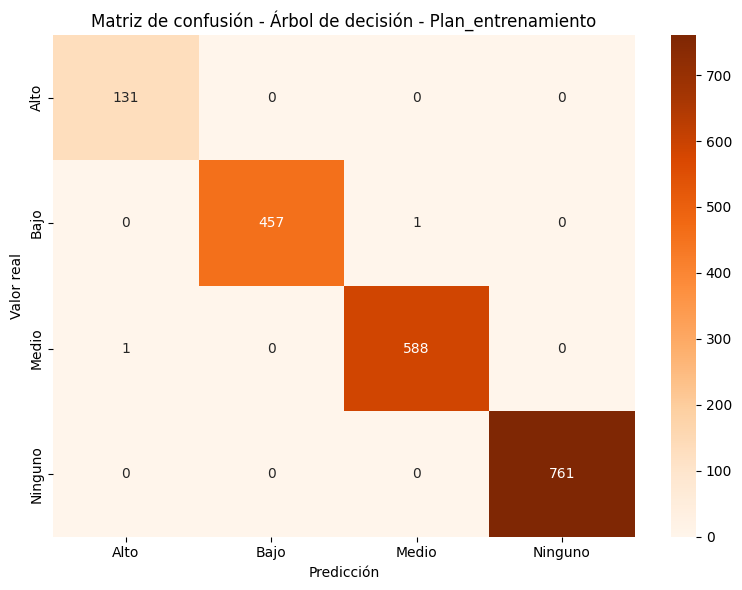

In [33]:
cm_tree_ent = confusion_matrix(tree_entrenamiento['y_test'], tree_entrenamiento['y_pred'])
labels_tree_ent = np.unique(tree_entrenamiento['y_test'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tree_ent, annot=True, fmt='d', cmap='Oranges',
            xticklabels=labels_tree_ent, yticklabels=labels_tree_ent)
plt.title('Matriz de confusión - Árbol de decisión - Plan_entrenamiento')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

### 4.7. Modelo basado en árbol de decisión para `Plan_nutrición`

Ahora vamos a entrenar el segundo modelo basado en árbol de decisión, esta vez para predecir la recomendación de plan nutricional, lo haremos siguiendo el mismo flujo.

In [34]:
tree_nutricion = entrenar_arbol_decision(
    experimento=exp_tree_nut,
    nombre_objetivo='Plan_nutrición',
    scoring='f1_macro'
)

display(tree_nutricion['resultados'])

#mejores hiperparametros y reporte de clasificación
print("Mejores hiperparámetros para Plan_nutrición:")
print(tree_nutricion['grid'].best_params_)

print("\nReporte de clasificación en test:")
print(classification_report(
    tree_nutricion['y_test'],
    tree_nutricion['y_pred'],
    zero_division=0
))

Fitting 5 folds for each of 160 candidates, totalling 800 fits


,Objetivo,Mejor score CV,Mejor criterion,Mejor max_depth,Mejor min_samples_split,Mejor min_samples_leaf,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Plan_nutrición,0.995576,gini,7,20,1,0.99639,0.99684,0.996683,0.996757


Mejores hiperparámetros para Plan_nutrición:
{'model__criterion': 'gini', 'model__max_depth': 7, 'model__min_samples_leaf': 1, 'model__min_samples_split': 20}

Reporte de clasificación en test:
               precision    recall  f1-score   support

   Balanceado       1.00      1.00      1.00       859
       Basico       1.00      0.99      0.99       457
Especializado       1.00      1.00      1.00       118
     Sin plan       0.99      1.00      1.00       505

     accuracy                           1.00      1939
    macro avg       1.00      1.00      1.00      1939
 weighted avg       1.00      1.00      1.00      1939



### 4.8. Matriz de confusión del modelo para `Plan_nutrición`

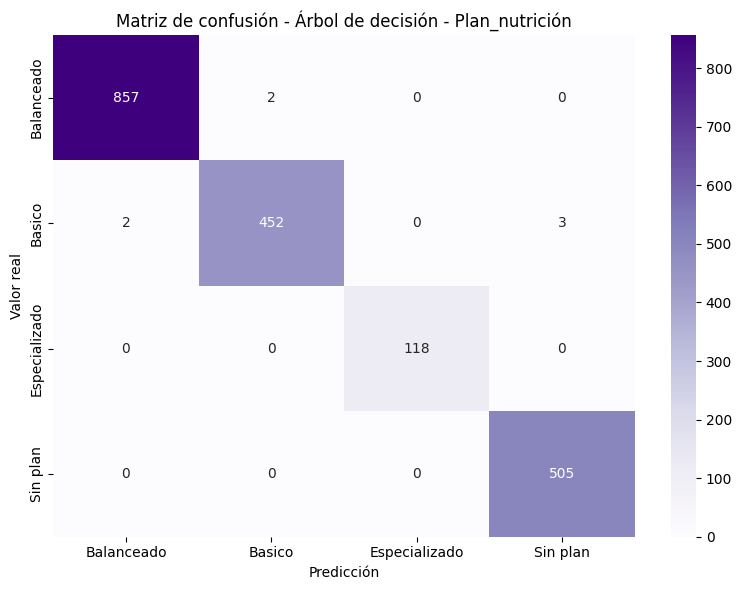

In [35]:
cm_tree_nut = confusion_matrix(tree_nutricion['y_test'], tree_nutricion['y_pred'])
labels_tree_nut = np.unique(tree_nutricion['y_test'])

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tree_nut, annot=True, fmt='d', cmap='Purples',
            xticklabels=labels_tree_nut, yticklabels=labels_tree_nut)
plt.title('Matriz de confusión - Árbol de decisión - Plan_nutrición')
plt.xlabel('Predicción')
plt.ylabel('Valor real')
plt.tight_layout()
plt.show()

### 4.9. Resumen de resultados de los modelos basados en árboles de decisión

In [36]:
resumen_arboles = pd.concat([
    tree_entrenamiento['resultados'],
    tree_nutricion['resultados']
], ignore_index=True)

display(resumen_arboles)

mejor_tree_ent = tree_entrenamiento['best_model']
mejor_tree_nut = tree_nutricion['best_model']

,Objetivo,Mejor score CV,Mejor criterion,Mejor max_depth,Mejor min_samples_split,Mejor min_samples_leaf,Accuracy test,Precision macro test,Recall macro test,F1 macro test
0,Plan_entrenamiento,0.998947,entropy,5,2,1,0.998969,0.997682,0.999030,0.998352
1,Plan_nutrición,0.995576,gini,7,20,1,0.996390,0.996840,0.996683,0.996757


### 4.10. Conclusión de los modelos basados en árboles de decisión

A partir de los resultados obtenidos, podemos ver que el desempeño de los árboles es comparable al de la regresión logística en algunos casos, aunque puede variar dependiendo de la variable objetivo. En particular, si el modelo para `Plan_entrenamiento` presenta un mejor rendimiento que el de `Plan_nutrición`, esto refuerza la idea de que la recomendación de planes nutricionales constituye un problema más complejo o con mayor nivel de ruido en los datos.

En comparación con la regresión logística, los árboles de decisión ofrecen una ventaja en términos de interpretabilidad, ya que permiten entender las reglas de decisión utilizadas para clasificar a los usuarios. Sin embargo, su desempeño puede ser más sensible a la variabilidad de los datos, lo que resalta la importancia de la validación cruzada en la selección del modelo.


## 5. Tabla comparativa de los 4 modelos

### 5.1 Tabla comparativa de los dos mejores modelos para el objetivo de **Plan de entrenamiento**.

In [ ]:
tabla_entrenamiento = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Precisión macro': log_entrenamiento['resultados']['Precision macro test'].values[0],
        'Recall macro': log_entrenamiento['resultados']['Recall macro test'].values[0],
        'F1 macro': log_entrenamiento['resultados']['F1 macro test'].values[0]
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Precisión macro': tree_entrenamiento['resultados']['Precision macro test'].values[0],
        'Recall macro': tree_entrenamiento['resultados']['Recall macro test'].values[0],
        'F1 macro': tree_entrenamiento['resultados']['F1 macro test'].values[0]
    }
])

print("Tabla comparativa — Plan de entrenamiento")
display(tabla_entrenamiento.round(4))

Tabla comparativa — Plan de entrenamiento


,Modelo,Precisión macro,Recall macro,F1 macro
0,Regresión Logística,0.8887,0.8907,0.8897
1,Árbol de Decisión,0.9977,0.9990,0.9984


Dado que se obtuvo un resultado casi perfecto en el modelo de árbol de decisión, revisamos la profundidad del arbol para ver si se evidencia sobreajuste (None o un valor muy alto):

In [45]:
print(f"Profunidad del árbol: {tree_entrenamiento['resultados']['Mejor max_depth'].values[0]}")

Profunidad del árbol: 5


### 5.2 Tabla comparativa de los dos mejores modelos para el objetivo de **Plan de nutrición**.

In [46]:
tabla_nutricion = pd.DataFrame([
    {
        'Modelo': 'Regresión Logística',
        'Precisión macro': log_nutricion['resultados']['Precision macro test'].values[0],
        'Recall macro': log_nutricion['resultados']['Recall macro test'].values[0],
        'F1 macro': log_nutricion['resultados']['F1 macro test'].values[0]
    },
    {
        'Modelo': 'Árbol de Decisión',
        'Precisión macro': tree_nutricion['resultados']['Precision macro test'].values[0],
        'Recall macro': tree_nutricion['resultados']['Recall macro test'].values[0],
        'F1 macro': tree_nutricion['resultados']['F1 macro test'].values[0]
    }
])

print("Tabla comparativa — Plan de nutrición")
display(tabla_nutricion.round(4))

Tabla comparativa — Plan de nutrición


,Modelo,Precisión macro,Recall macro,F1 macro
0,Regresión Logística,0.7511,0.6967,0.7164
1,Árbol de Decisión,0.9968,0.9967,0.9968


Dado que se obtuvo un resultado casi perfecto en el modelo de árbol de decisión, revisamos la profundidad del arbol para ver si se evidencia sobreajuste (None o un valor muy alto):

In [47]:
print(f"Profunidad del árbol: {tree_nutricion['resultados']['Mejor max_depth'].values[0]}")

Profunidad del árbol: 7


### 5.3 Interpretación de las métricas obtenidas y selección del mejor modelo.

Los cuatro modelos entrenados muestran diferencias importantes en su capacidad para predecir ambas variables objetivo.
En el caso de `Plan_entrenamiento`, la regresión logística alcanza una precisión macro de **0.8887**, recall de **0.8907** y F1-score de **0.8897**,
lo que indica que el modelo logra identificar correctamente la mayoría de las clases, aunque con cierta dificultad en las minoritarias,
dado que la precisión y el recall son similares y no hay una clase que esté siendo ignorada sistemáticamente.
El árbol de decisión, por su parte, obtiene una precisión de **0.9977**, recall de **0.999** y F1-score de **0.9984**, resultados notablemente superiores.

Para `Plan_nutrición`, la diferencia es aún más marcada, pues la regresión logística obtiene un F1-score de **0.7164**, reflejando que los límites
de decisión entre las clases nutricionales no son lineales y este modelo no logra capturarlos adecuadamente, mientras que el árbol alcanza
un F1-score de **0.9968**.

Respecto al posible sobreajuste, los hiperparámetros seleccionados por validación cruzada para el árbol de `Plan_entrenamiento` fueron
`max_depth=5` y `min_samples_split=2`, y para `Plan_nutrición` `max_depth=7` y `min_samples_split=20`, ambas profundidades moderadas
que descartan que el modelo haya memorizado los datos de entrenamiento.

Por lo tanto, se selecciona el **árbol de decisión como mejor modelo para ambos objetivos**, ya que supera consistentemente a la regresión
logística en todas las métricas evaluadas, con profundidades controladas que garantizan generalización, y captura de mejor manera
las relaciones no lineales presentes en los datos.

## 6. Identificación de las variables más relevantes en la predicción

### 6.1 Variables más relevantes en la predicción de **Plan de entrenamiento**

**Modelo de Árbol de Decisión:**

In [48]:
# Extraer nombres de columnas del preprocesador
feature_names = mejor_tree_ent.named_steps['preprocessor'].get_feature_names_out()

# Extraer importancias
importancias_tree_ent = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': mejor_tree_ent.named_steps['model'].feature_importances_
}).sort_values('Importancia', ascending=False)

display(importancias_tree_ent.head(10))

,Variable,Importancia
14,cat__Objetivo_Ganancia muscular,0.250385
28,cat__Nivel_experiencia_Avanzado,0.218234
25,cat__Nivel_Actividad_Alto,0.193269
4,num__Tiempo_disponible,0.191815
1,num__BMI,0.146298
5,num__Cigarrillos_dia,0.000000
6,num__Alcohol_semana,0.000000
7,num__Score_micronutrientes,0.000000
8,num__Ingesta_proteinas,0.000000
9,num__Pasos_dia,0.000000


**Modelo de Regresión logistica:**

In [49]:
feature_names = mejor_log_ent.named_steps['preprocessor'].get_feature_names_out()

importancias_log_ent = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': np.abs(mejor_log_ent.named_steps['model'].coef_).mean(axis=0)
}).sort_values('Importancia', ascending=False)

display(importancias_log_ent.head(10))

,Variable,Importancia
28,cat__Nivel_experiencia_Avanzado,15.512488
25,cat__Nivel_Actividad_Alto,15.465434
14,cat__Objetivo_Ganancia muscular,8.418699
4,num__Tiempo_disponible,2.932511
1,num__BMI,2.847487
18,cat__Condicion_salud_Asma,0.166941
21,cat__Condicion_salud_Hipertension,0.124664
11,cat__Genero_Femenino,0.118505
26,cat__Nivel_Actividad_Bajo,0.107379
17,cat__Objetivo_Resistencia,0.098176


### 6.2 Variables más relevantes en la predicción de **Plan de nutrición**

**Modelo de Árbol de Decisión:**

In [50]:
# Extraer nombres de columnas del preprocesador
feature_names = mejor_tree_nut.named_steps['preprocessor'].get_feature_names_out()

# Extraer importancias
importancias_tree_nut = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': mejor_tree_nut.named_steps['model'].feature_importances_
}).sort_values('Importancia', ascending=False)

display(importancias_tree_nut.head(10))

,Variable,Importancia
6,num__Alcohol_semana,0.220586
8,num__Ingesta_proteinas,0.197325
7,num__Score_micronutrientes,0.179947
17,cat__Objetivo_Resistencia,0.170743
1,num__BMI,0.129431
15,cat__Objetivo_General,0.101590
4,num__Tiempo_disponible,0.000378
3,num__Cantidad_equipo,0.000000
2,num__Horas_sueño,0.000000
9,num__Pasos_dia,0.000000


**Modelo de Regresión logistica:**

In [51]:
feature_names = mejor_log_nut.named_steps['preprocessor'].get_feature_names_out()

importancias_log_nut = pd.DataFrame({
    'Variable': feature_names,
    'Importancia': np.abs(mejor_log_nut.named_steps['model'].coef_).mean(axis=0)
}).sort_values('Importancia', ascending=False)

display(importancias_log_nut.head(10))

,Variable,Importancia
15,cat__Objetivo_General,4.266155
17,cat__Objetivo_Resistencia,4.147652
14,cat__Objetivo_Ganancia muscular,3.915664
16,cat__Objetivo_Perdida grasa,3.827014
7,num__Score_micronutrientes,1.605841
1,num__BMI,1.577436
6,num__Alcohol_semana,1.442560
8,num__Ingesta_proteinas,0.942674
18,cat__Condicion_salud_Asma,0.110354
13,cat__Genero_Otro,0.098336


### 6.3 Análisis de las variables más relevantes:

### Plan de entrenamiento

Ambos modelos coinciden en que las variables más determinantes para predecir el plan de 
entrenamiento son `Objetivo_Ganancia muscular`, `Nivel_experiencia_Avanzado`, 
`Nivel_Actividad_Alto` y `Tiempo_disponible`, lo cual tiene sentido desde la lógica del 
negocio, pues el objetivo fitness, la experiencia previa y la disponibilidad de tiempo son 
factores naturales que un entrenador consideraría al asignar un plan. El árbol de decisión 
concentra toda su capacidad predictiva en estas 5 variables (el resto tiene importancia 0.0), 
lo que sugiere que con pocas reglas bien definidas sobre estas características es suficiente 
para clasificar correctamente. La regresión logística, por su parte, distribuye la importancia 
de forma más amplia, incorporando variables como `Condicion_salud` y `Genero` con coeficientes 
pequeños pero no nulos, lo que refleja que este modelo considera más variables aunque con menor 
peso relativo.

### Plan de nutrición

Para el plan nutricional, los patrones cambian notablemente. El árbol de decisión identifica 
como variables clave `Alcohol_semana`, `Ingesta_proteinas`, `Score_micronutrientes` y `Objetivo`, 
es decir, variables directamente relacionadas con los hábitos alimenticios y el consumo de 
sustancias del usuario. La regresión logística, en cambio, otorga mayor peso al `Objetivo` del 
usuario en sus distintas categorías (`General`, `Resistencia`, `Ganancia muscular`, `Perdida grasa`), 
sugiriendo que desde una perspectiva lineal el objetivo fitness es el principal diferenciador del 
plan nutricional. La coincidencia de ambos modelos en variables como `BMI`, `Score_micronutrientes` 
e `Ingesta_proteinas` refuerza que estas características son genuinamente informativas para la 
recomendación nutricional, independientemente del enfoque de modelado utilizado.

## 7. Generación de predicciones sobre los datos no etiquetados utilizando el mejor modelo.

In [57]:
df_test = pd.read_csv('../data/Datos test Lab3.csv', sep=';', encoding='latin-1')

print(f'Dimensiones de los datos de test: {df_test.shape}')
display(df_test.head())

df_test_clean = limpieza_base_smartalpes(
    df_test,
    idx_grasa_eliminar=None,      # No eliminamos filas del test
    mapa_grasa_actualizar=None,
    eliminar_horas_sueno_invalidas=False,  # Tampoco eliminamos filas
    reducir_redundancia=True
)

# Construir X quitando las columnas objetivo vacías
X_test_final = df_test_clean.drop(columns=['Plan_entrenamiento', 'Plan_nutrición'])

# Predecir con los mejores modelos
df_test['Plan_entrenamiento'] = mejor_tree_ent.predict(X_test_final)
df_test['Plan_nutrición'] = mejor_tree_nut.predict(X_test_final)

# Verificar que no quedaron vacíos
print(f"Valores nulos de la predicción de Plan_entrenamiento: {df_test['Plan_entrenamiento'].isnull().sum()}")
print(f"Valores nulos de la predicción de Plan_nutrición: {df_test['Plan_nutrición'].isnull().sum()}")

# Vista previa
display(df_test[['Plan_entrenamiento', 'Plan_nutrición']].value_counts())

df_test.to_csv('../data/Datos test Lab3_predicciones.csv', sep=';',
               encoding='latin-1', index=False)
print("Archivo exportado correctamente")

df_verificacion = pd.read_csv('../data/Datos test Lab3_predicciones.csv', 
                               sep=';', encoding='latin-1')
print(f'Dimensiones de la predicción: {df_verificacion.shape}')
display(df_verificacion[['Plan_entrenamiento', 'Plan_nutrición']].head(10))

Dimensiones de los datos de test: (302, 26)


,Edad,Gnereo,Peso,Altura,BMI,Objetivo,Condicion_salud,Nivel_Actividad,Nivel_experiencia,Dieta_preferida,Horas_sueño,Entrenamiento_preferido,Cantidad_equipo,Tiempo_disponible,Tiene_alergia,Problemas_digestivos,Fumador,Cigarrillos_dia,Alcohol,Alcohol_semana,Score_micronutrientes,Ingesta_proteinas,Pasos_dia,Ingesta_agua,Plan_entrenamiento,Plan_nutrición
0,32,Femenino,77.3,1.54,32.59,Ganancia muscular,Lesion,Bajo,Intermedio,Vegetariano,9.4,Flexibilidad,6,120,0,0,0,0.0,0,0.0,0.21,169.0,8468,2.57,NaN,NaN
1,29,Masculino,79.6,1.82,24.03,General,Ninguno,Alto,Avanzado,Vegetariano,8.0,Cardio,2,34,0,0,0,0.0,0,0.0,0.58,52.4,11967,3.73,NaN,NaN
2,33,Femenino,107.2,1.57,43.49,General,Hipertension,Alto,Principiante,Vegano,9.4,Flexibilidad,1,52,0,0,0,0.0,0,0.0,0.37,189.5,15950,3.06,NaN,NaN
3,42,Femenino,103.5,1.67,37.11,General,Asma,Bajo,Principiante,No-Vegetariano,7.3,Fuerza,6,81,1,0,0,0.0,0,0.0,0.57,185.7,9384,2.18,NaN,NaN
4,29,Masculino,76.0,2.02,18.63,Ganancia muscular,Ninguno,Bajo,Intermedio,Pescetariano,7.4,Balance,3,114,1,0,0,0.0,1,23.7,0.21,182.1,10070,3.32,NaN,NaN


Valores nulos de la predicción de Plan_entrenamiento: 0
Valores nulos de la predicción de Plan_nutrición: 0


Plan_entrenamiento  Plan_nutrición
Medio               Balanceado        47
Ninguno             Sin plan          43
                    Balanceado        41
Bajo                Balanceado        34
Ninguno             Basico            33
Bajo                Sin plan          23
                    Basico            18
Medio               Basico            18
                    Sin plan          18
Alto                Balanceado        12
Medio               Especializado      5
Ninguno             Especializado      4
Bajo                Especializado      3
Alto                Basico             2
                    Sin plan           1
Name: count, dtype: int64

Archivo exportado correctamente
Dimensiones de la predicción: (302, 26)


,Plan_entrenamiento,Plan_nutrición
0,Medio,Balanceado
1,Medio,Sin plan
2,Medio,Basico
3,Bajo,Sin plan
4,Bajo,Balanceado
5,Medio,Balanceado
6,Bajo,Balanceado
7,Medio,Balanceado
8,Ninguno,Sin plan
9,Ninguno,Sin plan


## 8. Análisis de Resultados

- **¿Qué características del cliente parecen estar más relacionadas con el tipo de plan recomendado?**

- **¿Existen variables que podrían ser redundantes o poco informativas?**

- **¿El modelo logra reproducir adecuadamente las recomendaciones presentes en los datos?**

- **A partir de alguno de los modelos creados con árboles de decisión, describa en términos de reglas, las características que cumplen las variables involucradas en la recomendación que se da. Incluya además, la utilidad y la limitación que tienen este estilo de reglas en modelos de árboles de decisión principalmente en el proceso de explicabilidad del modelo.**

- **¿Cómo podría integrarse este tipo de modelo en una plataforma digital de fitness o bienestar?**

- **¿Qué limitaciones tendría utilizar un sistema automático para recomendar planes de entrenamiento?**

- **¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**



## 9. Uso de la IA Generativa

## 10. **Bono:** Modelo de clasificación multietiqueta 